In [9]:
import numpy as np
import xarray as xr
import advesi as adv
import matplotlib.pyplot as plt


Advect a rectangle with time

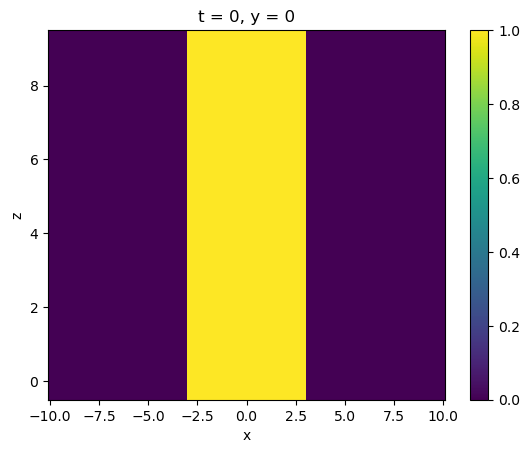

In [27]:
u=xr.DataArray(np.arange(-5,5), coords=[('z', np.arange(10))])
ff=adv.FlowField_Collection(u,0,0)
initial_field=xr.DataArray(np.zeros((100, 1,10)), coords=[('x', np.linspace(-10,10,100)), ('y', [0]), ('z', np.arange(10))])
initial_field=initial_field.where(np.logical_or(initial_field.x<-3, initial_field.x>3),other=1.0)
initial_field=initial_field.expand_dims(t=[0])
initial_field=adv.Field_Collection(initial_field)
initial_field.f.squeeze().plot(x='x', y='z')


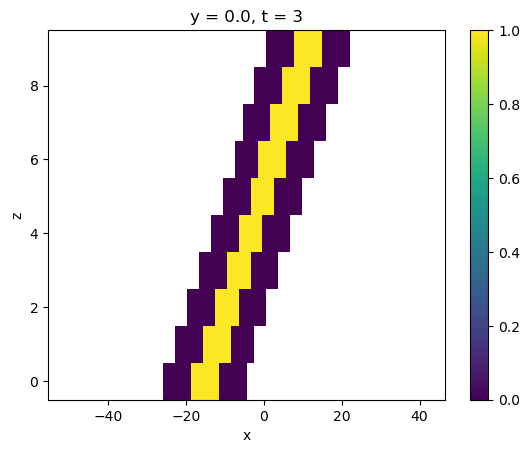

In [28]:
part_coll=adv.Particle_Collection.from_field_collection(initial_field)
advector=adv.EulerAdvector(dt=0.1, steps=100)
traj_coll=adv.Trajectory_Collection.from_flowfield(ff, initial_field.f.x, initial_field.f.y, initial_field.f.z, advector=advector)
resulting_fields=adv.Field_Collection.from_particle_collection(part_coll,traj_coll, np.arange(10),nx=100, ny=1, nz=10)
result=resulting_fields.f.squeeze()
result.isel(t=3).plot(x='x')


Simulate a single falling particle in a sheared field

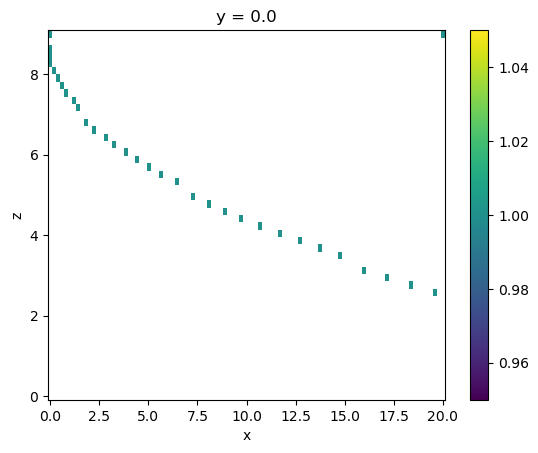

In [12]:
u=xr.DataArray(np.arange(10)[::-1], coords=[('z', np.arange(10))]).astype(float)
ff=adv.FlowField_Collection(u,0,-1.0)
advector=adv.EulerAdvector(dt=0.1, steps=100)
traj_coll=adv.Trajectory_Collection.from_flowfield(ff, x0=0.0,y0=0.0,z0=9.0,advector=advector)
part_coll=adv.Particle_Collection(0.0,0.0,9.0,0.0,1.0)
times=np.linspace(0.0,10.0,50)
path_coll=adv.Path_Collection.from_trajectory_collection(part_coll, traj_coll, t=times, matching='hybrid')
field=adv.Field_Collection.create_regular(times, [0,20], [0,0], [0,9], 100, 1,50)
field.fill_with(part_coll, path_coll)
f=field.f.squeeze()
f.max('t').plot(x='x')


Simulate multiple particles with different fallspeeds

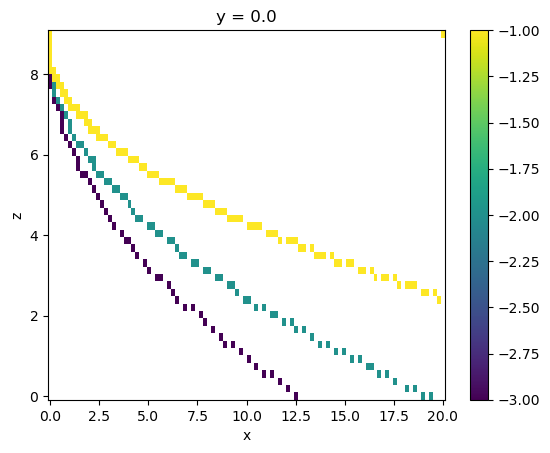

In [6]:
u=xr.DataArray(np.arange(10)[::-1], coords=[('z', np.arange(10))]).astype(float)
w=xr.DataArray([-1,-2,-3], coords=[('w0', [-1,-2,-3])]).astype(float)
ff=adv.FlowField_Collection(u,0,w)
traj_coll=adv.Trajectory_Collection.from_flowfield(ff, 0.0,0.0,9.0,0.1,100,savesteps=100)
part_coll=adv.Particle_Collection([0.0,0.0,0.0],0.0,9.0,0.0,[-1,-2,-3], field_selectors={'w0':[-1,-2,-3]})
path_times=np.linspace(0.0,10.0,200)
path_coll=adv.Path_Collection.from_trajectory_collection(part_coll, traj_coll, t=path_times, matching='hybrid')
field_times=np.linspace(0.0,10.0,5)
field=adv.Field_Collection.create_regular(field_times, [0,20], [0,0], [0,9], 100, 1,50)
field.fill_with(part_coll, path_coll)
f=field.f.squeeze()
f.max('t').plot(x='x')


Simulate a raining cloud (constant fallspeed of droplets)

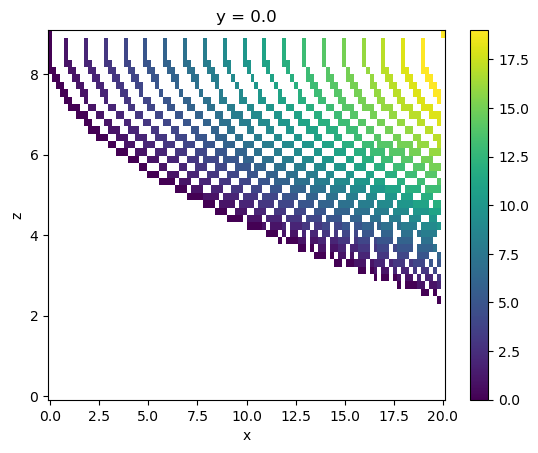

In [8]:
u=xr.DataArray(np.arange(10)[::-1], coords=[('z', np.arange(10))]).astype(float)
ff=adv.FlowField_Collection(u,0.0, -1.0)
x0=xr.DataArray(np.arange(20), coords=[('x0', np.arange(20))]).astype(float)
t0=xr.DataArray(np.linspace(0,1,20), coords=[('x0', x0.values)])
part_coll=adv.Particle_Collection(x0,0.0,9.0,t0, x0)
traj_coll=adv.Trajectory_Collection.from_flowfield(ff, x0.values,0.0,9.0,0.1,100,savesteps=100)
path_times=np.linspace(0.0,10.0,200)
path_coll=adv.Path_Collection.from_trajectory_collection(part_coll, traj_coll, t=path_times, matching='hybrid')
field_times=np.linspace(0.0,10.0,5)
field=adv.Field_Collection.create_regular(field_times, [0,20], [0,0], [0,9], 100, 1,50)
field.fill_with(part_coll, path_coll)
f=field.f.squeeze()
f.max('t').plot(x='x')


Simulate a raining cloud with size sorting: Setup cloud and paths

In [10]:
u_top=10.0
zsize=4.0
xsize=40.0
vmin=-3
vmax=-2
time_max=xsize/u_top
z=np.linspace(0,zsize,20)
z[0]=-np.inf
z[-1]=np.inf
u=xr.DataArray(np.linspace(u_top/2.0,u_top,20), coords=[('z',z )]).astype(float)
w=xr.DataArray(np.linspace(vmin, vmax,10), coords=[('w0', np.linspace(vmin, vmax,10))])
ff=adv.FlowField_Collection(u,0.0, w)
x0=xr.DataArray(np.linspace(0,xsize,100), coords=[('x0', np.linspace(0,xsize,100))]).astype(float)
t0=xr.DataArray(np.linspace(0,time_max,100), coords=[('x0', x0.values)])
part_coll=adv.Particle_Collection(x0,0.0, zsize,t0, w, field_selectors={'w0':w})
traj_coll=adv.Trajectory_Collection.from_flowfield(ff, x0.values,0.0,zsize,dt=0.1,steps=200, steps_backward=0,savesteps=200, interp_method='interpolate')
path_times=np.linspace(0.0,time_max,200)
path_coll=adv.Path_Collection.from_trajectory_collection(part_coll, traj_coll, t=path_times, matching='hybrid')

/scratch-local/Paul.Ockenfuss/virtual_environments/mamba_envs/standard/lib/python3.12/site-packages/xarray/core/missing.py:588: RuntimeWarning: All-NaN slice encountered
  minval = np.nanmin(new_x_loaded)
/scratch-local/Paul.Ockenfuss/virtual_environments/mamba_envs/standard/lib/python3.12/site-packages/xarray/core/missing.py:589: RuntimeWarning: All-NaN slice encountered
  maxval = np.nanmax(new_x_loaded)



Spatial view

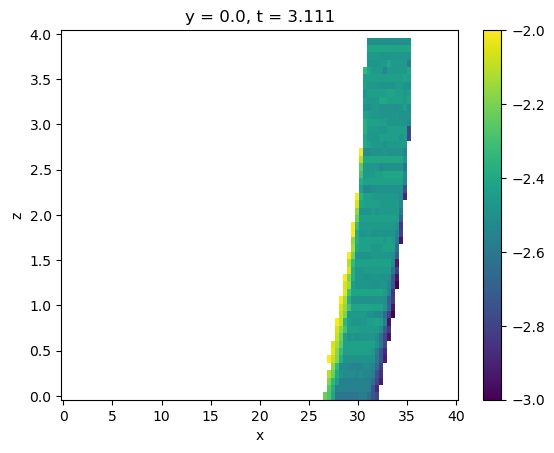

In [11]:
field_times=np.linspace(0.0,time_max,10)
field=adv.Field_Collection.create_regular(field_times, [0,xsize], [0,0], [0,zsize], 100, 1,50)
field.fill_with(part_coll, path_coll, aggregation='mean')
f=field.f.squeeze()
f.isel(t=7).plot(x='x', vmin=vmin, vmax=vmax)


"Birdbath scan" View

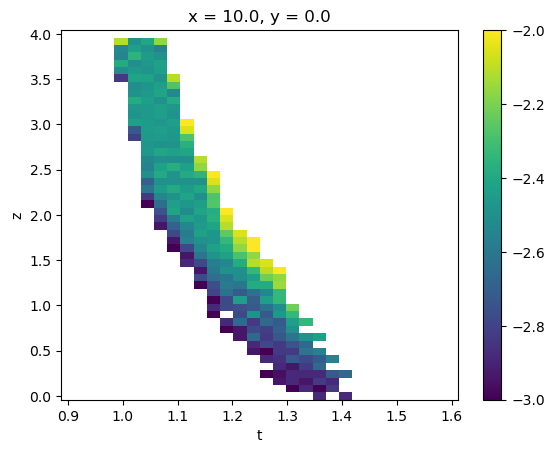

In [12]:
field_times=np.linspace(0.9,1.6,30)
field=adv.Field_Collection.create_regular(field_times, [10,11], [0,0], [0,zsize], 2, 1,50)
field.fill_with(part_coll, path_coll, aggregation='mean')
f=field.f.squeeze()
f.sel(x=10, method='nearest').plot(x='t', vmin=vmin, vmax=vmax)

Time dependent wind field: A single particle is advected with increasing wind speed. In this case, we can not precalculate trajectories. Let's create the field: after one unit in time, the speed increases from 1 to 2 in x direction

In [15]:
u=xr.DataArray([1,2], coords=[('t', [0,1])])
flowfield=adv.FlowField_Collection(u,0,0)
part_coll=adv.Particle_Collection(x0=0.0, y0=0.0, z0=0.0, t0=0.0, property=1.0)

We see the speedup in the particle path. Since we use 0.1 timesteps and "nearest" speed selection, the higher speed is visible after 5 timesteps

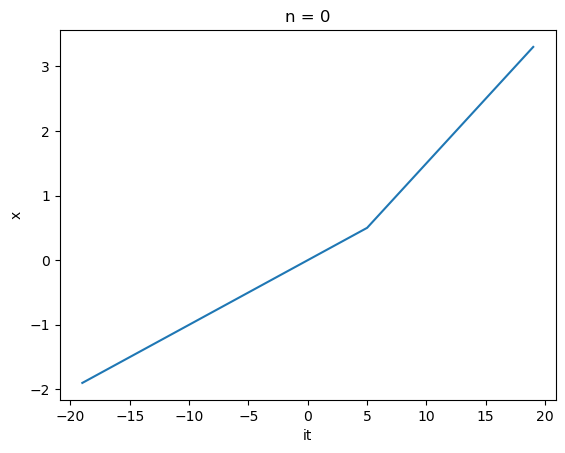

In [ ]:
advector=adv.EulerAdvector(dt=0.1, steps=20, steps_backward=20, interp_method='nearest')
path_coll=adv.Path_Collection.from_flowfield_collection(part_coll, flowfield, advector)
path_coll.ds.x.squeeze().plot(x='it')

However, if we choose to interpolate the speed, we get a parabolic path! This makes sense for a linear increase in speed. Note how, for longer times backward, the particles moves up again, since the field velocity will be negative at those times!

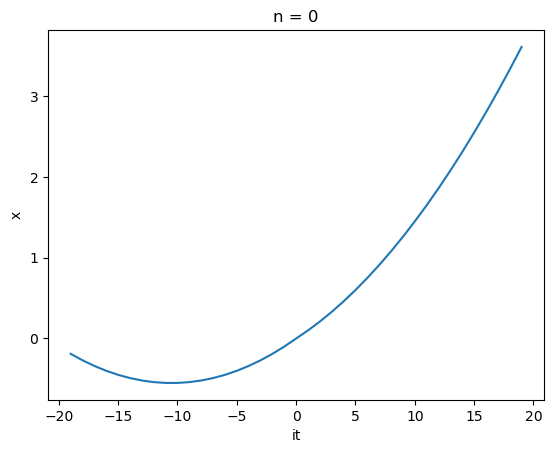

In [ ]:
advector=adv.EulerAdvector(dt=0.1, steps=20, steps_backward=20, interp_method='interpolate')
path_coll=adv.Path_Collection.from_flowfield_collection(part_coll, flowfield, advector)
path_coll.ds.x.squeeze().plot(x='it')

Let's simulate multiple falling particles in a field with increasing wind speed: You can see how the particles continuously fall and at the same time, due to the increasing wind, experience a faster advection into the x direction.

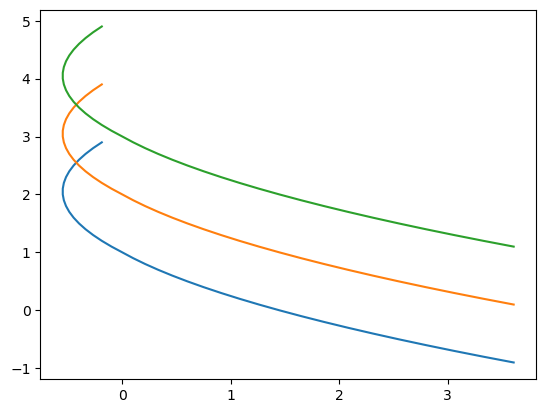

In [ ]:
u=xr.DataArray([1,2], coords=[('t', [0,1])])
flowfield=adv.FlowField_Collection(u,0,-1)
part_coll=adv.Particle_Collection(x0=0.0, y0=0.0, z0=[1,2,3], t0=0.0, property=[1,2,3])
path_coll=adv.Path_Collection.from_flowfield_collection(part_coll, flowfield, advector)
fig,ax=plt.subplots()
for n in range(3):
    ax.plot(path_coll.ds.x.isel(n=n), path_coll.ds.z.isel(n=n))

Instead of plotting the paths, we can again make a grid and fill it with the particle paths:

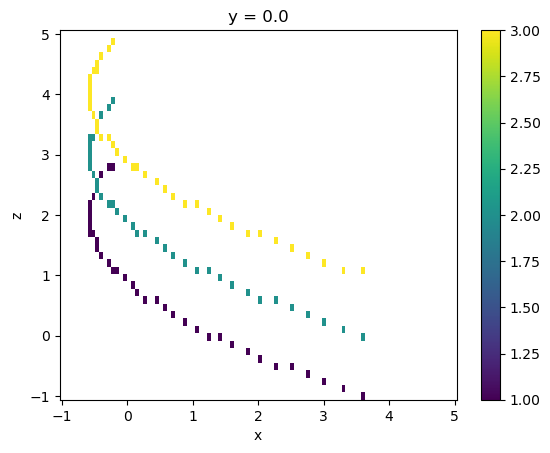

In [ ]:
times=np.linspace(-2,2,20) #20 snapshots between time -2 and 2
field=adv.Field_Collection.create_regular(times, [-1,5], [0,0], [-1,5], 100, 1,50)
field.fill_with(part_coll, path_coll)
f=field.f.squeeze()
f.max('t').plot(x='x') #plot all snapshots at once